# Global sensitivity analysis & scenario discovery

This notebook is the runnable companion of the step-by-step tutorial
([HTML version](../docs/tutorial-gsa-and-scenario-discovery.html)). It adds two standard
uncertainty-analysis tools on top of the workflow shown in the
[Insulation tutorial](Insulation.ipynb), using the same SEVEN-project peak-energy model.

- **Global sensitivity analysis (GSA)** — *which uncertain parameters drive the variance
  of the outcome?* Variance-based Sobol indices (first-order `S1` and total-order `ST`).
  This differs from intervention ranking (which ranks *levers*) and from one-factor-at-a-
  time analysis (GSA captures interactions).
- **Scenario discovery** — *which combinations of uncertain inputs lead to a bad outcome?*
  PRIM/CART find interpretable regions (boxes/rules) of the input space where cases of
  concern concentrate, reported with **density** (precision) and **coverage** (recall).

Together: GSA tells you *which assumptions your conclusion is most sensitive to*; scenario
discovery tells you *which combinations of conditions produce the bad outcome*.

In [1]:
from sip_systemsinsightpipeline import Extract, SDM, discover_scenarios
from sip_systemsinsightpipeline.plots import (plot_gsa, plot_moment_independent,
                                              plot_scenario_tradeoff, plot_scenario_box)

s = Extract('Insulation_PeakEnergy.xlsx').extract_settings()
s.seed = 0
s.N = 1
s.t_end = 15
s.time_unit = 'years'
s.parameter_value_aux = 0.3
s.parameter_value_stocks = 0.1
sdm = SDM(s)
voi = s.variable_of_interest[0]
print('free uncertain parameters:', len(sdm._gsa_parameter_spec()[0]))

Variable of interest: Percentage of electricity use during peak hours (16.00-21.00) on household level
with 51 intervention variables

21 feedback loops of maximum length 5
All loops have at least one stock
No interaction terms specified so will solve linear SDM.
free uncertain parameters: 94


## 1. Global sensitivity analysis

`run_GSA` draws a Saltelli/Sobol design over the model's uncertain parameters (the same
uniform priors `run_simulations` samples from), evaluates the model once per design point
under a chosen intervention scenario (here the default: every intervention applied at unit
intensity), reduces each run to the outcome, and estimates Sobol indices.

Total runs = `n * (d + 2)`, so keep `n` modest for a first look on a large model.

In [2]:
# n is small here so the notebook runs quickly; raise it (e.g. 512+) for tighter CIs.
gsa_df = sdm.run_GSA(voi, n=64, seed=1)
gsa_df.head(12)

GSA: evaluating Sobol design:   0%|          | 0/6144 [00:00<?, ?it/s]

GSA: evaluating Sobol design:   0%|          | 12/6144 [00:00<00:52, 115.89it/s]

GSA: evaluating Sobol design:   0%|          | 24/6144 [00:00<00:54, 112.08it/s]

GSA: evaluating Sobol design:   1%|          | 36/6144 [00:00<00:54, 111.60it/s]

GSA: evaluating Sobol design:   1%|          | 48/6144 [00:00<00:54, 112.37it/s]

...

GSA: evaluating Sobol design: 100%|█████████▉| 6119/6144 [00:59<00:00, 111.84it/s]

GSA: evaluating Sobol design: 100%|█████████▉| 6131/6144 [00:59<00:00, 112.70it/s]

GSA: evaluating Sobol design: 100%|█████████▉| 6143/6144 [00:59<00:00, 113.65it/s]

GSA: evaluating Sobol design: 100%|██████████| 6144/6144 [00:59<00:00, 103.67it/s]

,parameter,S1,S1_low,S1_high,S1_conf,ST,ST_low,ST_high,ST_conf
0,Percentage of electricity use during peak hour...,0.504332,0.0,1.000000,0.500000,0.422221,0.288478,0.646946,0.179234
1,Percentage of electricity use during peak hour...,0.524616,0.0,1.000000,0.500000,0.222942,0.147813,0.378935,0.115561
2,Percentage of electricity use during peak hour...,0.022942,0.0,0.306724,0.153362,0.056406,0.037515,0.080442,0.021464
3,Percentage of electricity use during peak hour...,0.090619,0.0,0.372850,0.186425,0.053382,0.036273,0.076760,0.020243
4,Percentage of electricity that is smart-contro...,0.000000,0.0,0.253563,0.126782,0.031851,0.017817,0.050687,0.016435
5,Preceived cost savings <- Percentage of electr...,0.026195,0.0,0.236491,0.118245,0.027763,0.015344,0.048584,0.016620
6,Degree of controllability of electricity use (...,0.097804,0.0,0.347731,0.173865,0.022670,0.013056,0.032905,0.009924
7,Willingness to adopt flexible electricity usag...,0.049826,0.0,0.239619,0.119810,0.010561,0.005633,0.017922,0.006145
8,Percentage of electricity that is smart-contro...,0.073376,0.0,0.220431,0.110216,0.008964,0.005108,0.016626,0.005759
9,Willingness to adopt flexible electricity usag...,0.014667,0.0,0.132814,0.066407,0.008263,0.005881,0.012284,0.003201


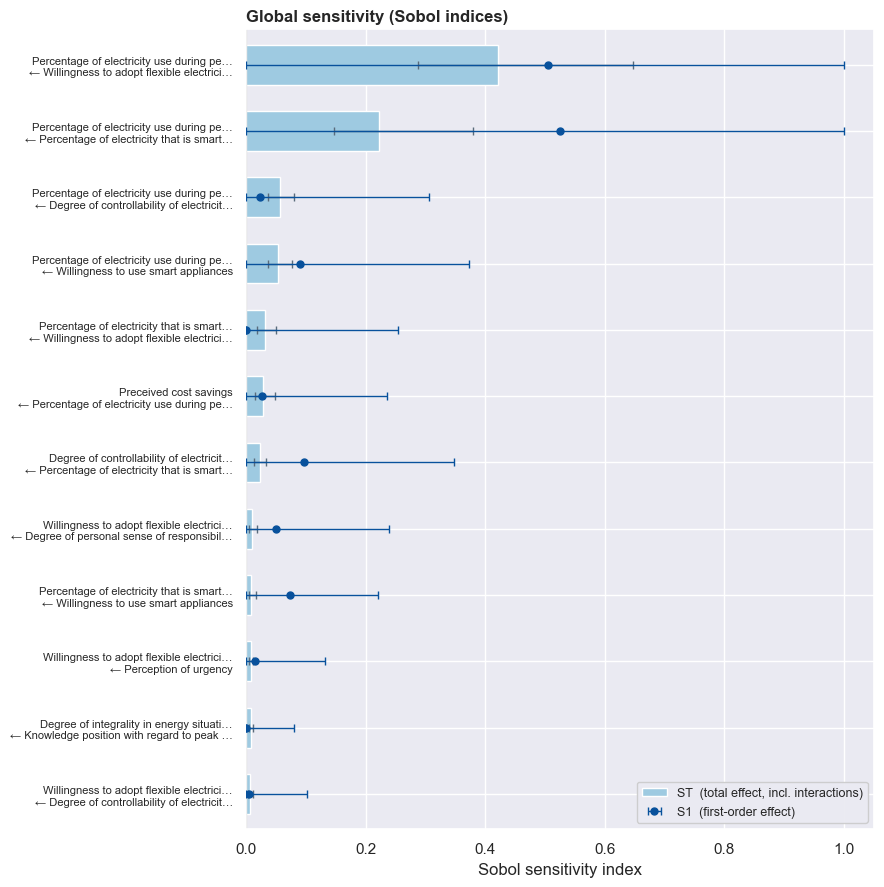

In [3]:
# Sobol tornado: total-order ST (bars) with first-order S1 (markers) and CI whiskers.
fig = plot_gsa(gsa_df, top=12)

**How to read it.** `ST` (total-order) is the share of outcome variance a parameter drives
*including* its interactions with others; `S1` (first-order) is its effect alone. A large
`ST` with small `S1` means the parameter matters mostly *through interactions*. Parameters
at the top are where better evidence would most reduce the uncertainty in your conclusions.
Wide confidence whiskers mean `n` is too small — increase it.

Sobol indices live in `[0, 1]`, but their estimator (a difference of variances) can dip
slightly negative for an unimportant parameter at finite `n`. `run_GSA` therefore projects
the estimate and its confidence interval onto `[0, 1]` by default (`clip=True`), so such a
parameter reports `S1 = 0` with a one-sided interval like `[0, 0.05]` ('indistinguishable
from zero'). The interval columns `S1_low`/`S1_high` (and `ST_low`/`ST_high`) are an
*asymmetric* **BCa** (bias-corrected, accelerated) bootstrap, which is the right shape near
the 0/1 boundary; pass `ci='percentile'` for the plain bootstrap or `clip=False` for the raw
estimates as a convergence diagnostic. See [Choosing a sensitivity method](../docs/sensitivity-methods.html) for the estimator theory.

## 2. Beyond variance: distributional importance (δ and PAWN)

Variance is only one feature of the output distribution. **Moment-independent** measures
look at the shift in the *whole distribution* an input induces — they are non-negative by
construction (so no spurious negatives) and run on a plain Monte-Carlo ensemble (`n` runs,
not `n*(d+2)`). Borgonovo's `delta` also returns the given-data first-order Sobol `S1`.

GSA: evaluating Sobol design:   0%|          | 0/1000 [00:00<?, ?it/s]

GSA: evaluating Sobol design:   1%|          | 12/1000 [00:00<00:08, 116.97it/s]

GSA: evaluating Sobol design:   2%|▏         | 24/1000 [00:00<00:08, 115.69it/s]

GSA: evaluating Sobol design:   4%|▎         | 36/1000 [00:00<00:08, 112.80it/s]

GSA: evaluating Sobol design:   5%|▍         | 48/1000 [00:00<00:08, 114.45it/s]

...

GSA: evaluating Sobol design:  97%|█████████▋| 970/1000 [00:08<00:00, 111.80it/s]

GSA: evaluating Sobol design:  98%|█████████▊| 982/1000 [00:08<00:00, 111.94it/s]

GSA: evaluating Sobol design:  99%|█████████▉| 994/1000 [00:08<00:00, 112.30it/s]

GSA: evaluating Sobol design: 100%|██████████| 1000/1000 [00:08<00:00, 111.87it/s]

,parameter,delta,delta_conf,S1,S1_conf
0,Percentage of electricity use during peak hour...,0.249389,0.023467,0.472741,0.044835
1,Percentage of electricity use during peak hour...,0.184887,0.022591,0.246265,0.040657
2,Percentage of electricity use during peak hour...,0.130918,0.019140,0.025578,0.019030
3,Descriptive norm <- Degree of visibility of el...,0.110682,0.016018,0.007632,0.011846
4,Percentage of electricity usage that is manual...,0.104685,0.014473,0.016737,0.008043
5,Perceived agency in shifting electricity usage...,0.104054,0.019616,0.013724,0.010887
6,Willingness to adopt flexible electricity usag...,0.101670,0.016982,0.004533,0.011757
7,Willingness to adopt flexible electricity usag...,0.101539,0.018721,0.019431,0.014524


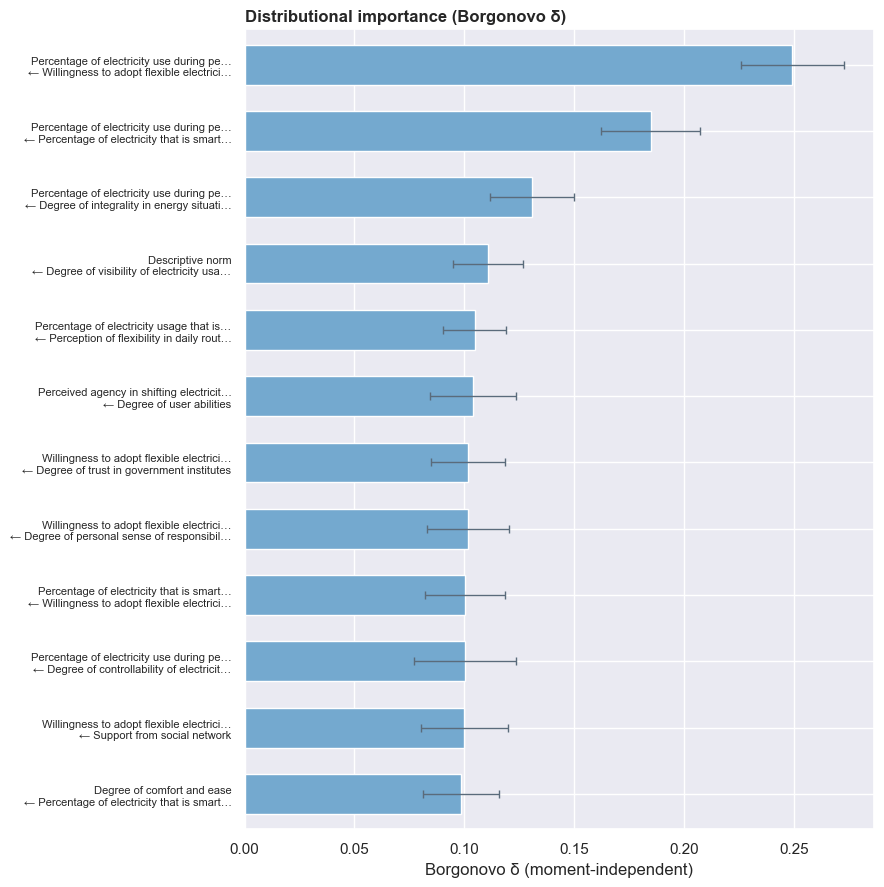

In [4]:
delta_df = sdm.run_GSA(voi, method='delta', n=1000, seed=2)
fig = plot_moment_independent(delta_df, measure='delta', top=12)
delta_df.head(8)

**How to read it.** δ is the expected normalised shift in the outcome *density* when a
parameter is fixed; it captures effects on all moments (tails, skew), not just variance. The
strongest drivers usually agree with the Sobol ranking — but δ can surface inputs whose
effect is interaction-driven (on the textbook Ishigami function, `x3` has Sobol `S1 ~ 0` yet
`δ ~ 0.16`). PAWN (`method='pawn'`) is a CDF-based alternative with the same spirit.

In [5]:
pawn_df = sdm.run_GSA(voi, method='pawn', n=1000, seed=2)
pawn_df.head(8)

GSA: evaluating Sobol design:   0%|          | 0/1000 [00:00<?, ?it/s]

GSA: evaluating Sobol design:   1%|          | 12/1000 [00:00<00:08, 113.04it/s]

GSA: evaluating Sobol design:   2%|▏         | 24/1000 [00:00<00:08, 114.05it/s]

GSA: evaluating Sobol design:   4%|▎         | 36/1000 [00:00<00:08, 113.82it/s]

GSA: evaluating Sobol design:   5%|▍         | 48/1000 [00:00<00:08, 113.75it/s]

...

GSA: evaluating Sobol design:  97%|█████████▋| 974/1000 [00:08<00:00, 112.20it/s]

GSA: evaluating Sobol design:  99%|█████████▊| 986/1000 [00:08<00:00, 112.95it/s]

GSA: evaluating Sobol design: 100%|█████████▉| 998/1000 [00:08<00:00, 113.96it/s]

GSA: evaluating Sobol design: 100%|██████████| 1000/1000 [00:08<00:00, 115.55it/s]

,parameter,pawn_median,pawn_mean,pawn_cv
0,Percentage of electricity use during peak hour...,0.287000,0.312388,0.371557
1,Percentage of electricity use during peak hour...,0.199500,0.196897,0.462829
2,Percentage of electricity use during peak hour...,0.145000,0.136116,0.304942
3,Willingness to adopt flexible electricity usag...,0.113500,0.114384,0.367802
4,Percentage of electricity use during peak hour...,0.109500,0.120746,0.386312
5,Preceived cost savings <- Percentage of electr...,0.106000,0.112996,0.378665
6,Willingness to adopt flexible electricity usag...,0.105879,0.110176,0.331911
7,Willingness to adopt flexible electricity usag...,0.103000,0.100874,0.309911


## 3. Scenario discovery

`sample_outcomes` draws an independent ensemble of parameter sets and their outcomes;
`discover_scenarios` then localises the region of input space where the *cases of concern*
concentrate. Here the concern is that peak-hour electricity use stays **high** (least
reduced) despite the full intervention package.

In [6]:
X, y = sdm.sample_outcomes(n=1500, seed=2)
import numpy as np
threshold = float(np.quantile(y, 0.8))   # worst 20% of outcomes = 'high peak use'

result = discover_scenarios(X, y, threshold=threshold, direction='above',
                            method='prim', peel_alpha=0.05, min_coverage=0.5)
box = result.box
print('density (precision):', round(box.density, 3))
print('coverage (recall)  :', round(box.coverage, 3))
print('mass               :', round(box.mass, 3))
box.limits

GSA: evaluating Sobol design:   0%|          | 0/1500 [00:00<?, ?it/s]

GSA: evaluating Sobol design:   1%|          | 12/1500 [00:00<00:12, 118.75it/s]

GSA: evaluating Sobol design:   2%|▏         | 24/1500 [00:00<00:12, 117.03it/s]

GSA: evaluating Sobol design:   2%|▏         | 36/1500 [00:00<00:12, 114.96it/s]

GSA: evaluating Sobol design:   3%|▎         | 48/1500 [00:00<00:12, 114.33it/s]

...

GSA: evaluating Sobol design:  99%|█████████▊| 1478/1500 [00:12<00:00, 114.97it/s]

GSA: evaluating Sobol design:  99%|█████████▉| 1490/1500 [00:12<00:00, 112.97it/s]

GSA: evaluating Sobol design: 100%|██████████| 1500/1500 [00:12<00:00, 115.91it/s]

density (precision): 0.837
coverage (recall)  : 0.513
mass               : 0.123


,min,max
dimension,,
Percentage of electricity that is smart-controlled <- Willingness to adopt flexible electricity usage,0.000124,0.094441
Percentage of electricity that is smart-controlled <- Policy agreement for smart appliances,0.006350,0.099966
Degree of controllability of electricity use (in/out of peak) <- Degree of HEMS usage,0.000067,0.094930
Knowledge position with regard to peak usage and net congestion <- Comprehensibility of tariff structures,0.000021,0.096808
Percentage of electricity use during peak hours (16.00-21.00) on household level <- Percentage of electricity that is smart-controlled,-0.056544,-0.000170
Percentage of electricity use during peak hours (16.00-21.00) on household level <- Degree of controllability of electricity use (in/out of peak),-0.094437,-0.000051
Percentage of electricity use during peak hours (16.00-21.00) on household level <- Preceived cost savings,-0.094272,-0.000004
Percentage of electricity use during peak hours (16.00-21.00) on household level <- Willingness to adopt flexible electricity usage,-0.031434,-0.000085
Percentage of electricity use during peak hours (16.00-21.00) on household level <- Willingness to use smart appliances,-0.095212,-0.000191


**How to read it.** PRIM *peels* the input box to raise **density** (the share of points
inside that are cases of concern) while watching **coverage** (the share of all concerning
cases still captured). `box.limits` lists only the dimensions PRIM actually had to restrict
— the parameters whose values jointly produce the bad outcome; everything else is left
unconstrained, which is itself the finding.

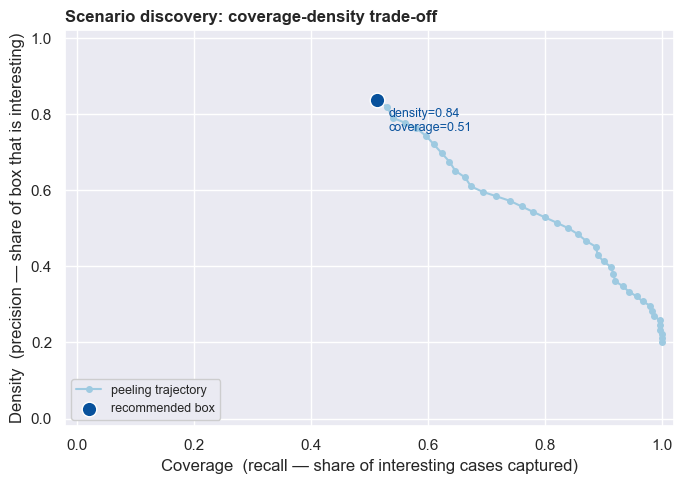

In [7]:
fig = plot_scenario_tradeoff(result)

The peeling curve shows the coverage-density trade-off: each step sacrifices some coverage
to gain density. The highlighted point is the recommended box; pick a different point if you
prefer broader coverage over tighter precision.

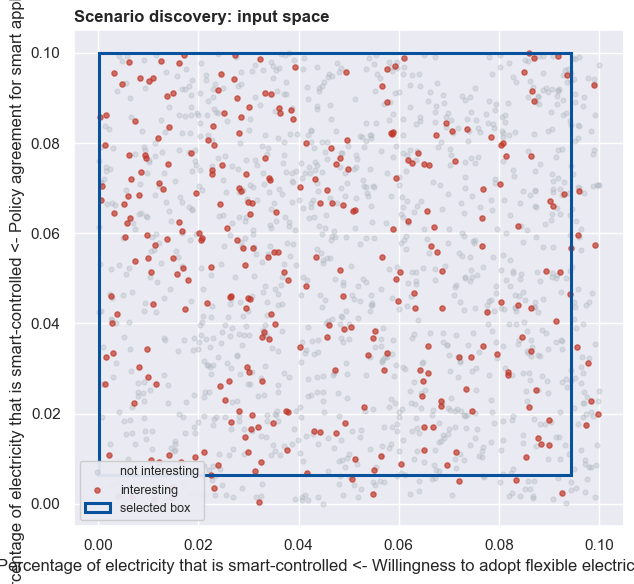

In [8]:
# Scatter the two most-restricted inputs, coloured by concern, with the box drawn.
rdims = box.restricted_dimensions
if len(rdims) >= 2:
    fig = plot_scenario_box(result, rdims[0], rdims[1], X)
else:
    print('Only one dimension was restricted:', rdims)

## 4. CART: the same question as a decision tree

CART is an alternative that recovers axis-aligned rules; it is good for cross-checking which
variables matter (the splitting variables) and for non-box-shaped regions.

In [9]:
res_cart = discover_scenarios(X, y, threshold=threshold, direction='above',
                              method='cart', max_depth=3, min_density=0.7, seed=0)
print('splitting variables:', res_cart.splitting_variables)
for rule in res_cart.rules[:3]:
    print(' -', rule)

splitting variables: ['Percentage of electricity use during peak hours (16.00-21.00) on household level <- Degree of controllability of electricity use (in/out of peak)', 'Percentage of electricity use during peak hours (16.00-21.00) on household level <- Degree of integrality in energy situation in households', 'Percentage of electricity use during peak hours (16.00-21.00) on household level <- Percentage of electricity that is smart-controlled', 'Percentage of electricity use during peak hours (16.00-21.00) on household level <- Willingness to adopt flexible electricity usage']
 - Percentage of electricity use during peak hours (16.00-21.00) on household level <- Willingness to adopt flexible electricity usage > -0.03112 and Percentage of electricity use during peak hours (16.00-21.00) on household level <- Percentage of electricity that is smart-controlled > -0.05179 and Percentage of electricity use during peak hours (16.00-21.00) on household level <- Degree of controllability of 

## References

- Saltelli, A. et al. (2008). *Global Sensitivity Analysis: The Primer.* Wiley.
- Sobol', I. M. (2001). Global sensitivity indices for nonlinear mathematical models and
  their Monte Carlo estimates. *Mathematics and Computers in Simulation*, 55(1-3).
- Friedman, J. H. & Fisher, N. I. (1999). Bump hunting in high-dimensional data.
  *Statistics and Computing*, 9(2).
- Kwakkel, J. H. & Jaxa-Rozen, M. (2016). Improving scenario discovery for handling
  heterogeneous uncertainties. *Environmental Modelling & Software*, 79.
- Herman, J. & Usher, W. (2017). SALib: An open-source Python library for sensitivity
  analysis. *Journal of Open Source Software*, 2(9).